# Fashion Retail Data Analysis & Expansion Strategy

The fashion retail industry is characterized by strong competition, changing consumer preferences, and the continuous need for geographic expansion. In this context, data analysis can support strategic decisions regarding store performance, product demand, and market opportunities.

This project analyzes a multinational fashion retail dataset to evaluate sales performance, store efficiency, product demand, and potential expansion opportunities.

The topic is economically relevant because retail revenue is influenced by store location, product category, customer demand, and pricing policies. By examining these factors, the analysis highlights the main differences between markets and identifies patterns useful for expansion decisions.

The project is developed in Python, using Google Colab, and includes methods such as data preparation, merge/join operations, grouping and aggregation, graphical representation, treatment of missing and extreme values, encoding, scaling, clustering, regression, and spatial analysis.

## Dataset Presentation

The dataset used in this project contains information on fashion retail transactions, stores, and products. It is composed of three main files:

- **transactions.csv** – includes transaction-level information such as invoice ID, customer ID, product ID, quantity, discount, date, and line total;
- **stores.csv** – includes information about store location, country, city, and coordinates;
- **products.csv** – includes product-level information such as category, sub-category, and production cost.

Together, these files allow the construction of an integrated dataset that supports the analysis of sales, store performance, product structure, and geographic expansion opportunities.

## Software Packages Used

The project was developed in Python using Google Colab. The main packages used are:

- **pandas** for data loading, cleaning, grouping, aggregation, and merge/join operations
- **numpy** for numerical operations
- **matplotlib** for graphical representation of the data
- **scikit-learn** for encoding, scaling, and clustering
- **statsmodels** for multiple regression analysis
- **geopandas** for spatial representation of store locations

In [1]:
#Check if package is avilable
try:
    import sklearn
    print('Import OK.')
except ImportError as err:
    print(err)

Import OK.


In [2]:
# Upload files in Colab
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/Colab Notebooks/Project"

Mounted at /content/drive


## 1. Reading, Merging, and Preparing the Datasets

### a) Defining the problem
The first step of the analysis is to load the available retail datasets and combine them into a single working database. Since the information is distributed across transactions, stores, and products, the data must be merged before any descriptive, graphical, or predictive analysis can be performed.

### b) Information required for solving
This step requires the following files:
- `transactions.csv`
- `stores.csv`
- `products.csv`

The transactions file contains sales information, the stores file contains geographic information, and the products file contains category-level information.

### c) Calculation methods, algorithms, calculation formulas used
The datasets are loaded using the `read_csv()` function from the pandas package. A random sample of 50,000 transactions is selected in order to reduce memory usage and ensure efficient processing in Google Colab.

The datasets are then merged using the common keys:
- `Product ID`
- `Store ID`

After merging, only the variables relevant for the analysis are selected. The date variable is converted to datetime format, and several country, city, and store names are standardized for consistency in graphical representation.

### d) Presentation of results
The result of this step is a clean merged dataset containing transaction-level, product-level, and store-level information, ready for analysis.

### e) Economic interpretation
Integrating the three datasets makes it possible to analyze sales not only at transaction level, but also by product category and geographic location. This provides a broader business perspective and supports more realistic expansion analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

path = "/content/drive/MyDrive/Colab Notebooks/Project/"

# Load the data
print("Loading datasets...")
df_transactions = pd.read_csv(path+'transactions.csv')
df_stores = pd.read_csv(path+'stores.csv')
df_products = pd.read_csv(path+'products.csv')

print("Data loaded successfully!")
print("Transactions columns:", df_transactions.columns.tolist())
print("Stores columns:", df_stores.columns.tolist())
print("Products columns:", df_products.columns.tolist())

Loading datasets...
Data loaded successfully!
Transactions columns: ['Invoice ID', 'Line', 'Customer ID', 'Product ID', 'Size', 'Color', 'Unit Price', 'Quantity', 'Date', 'Discount', 'Line Total', 'Store ID', 'Employee ID', 'Currency', 'Currency Symbol', 'SKU', 'Transaction Type', 'Payment Method', 'Invoice Total']
Stores columns: ['Store ID', 'Country', 'City', 'Store Name', 'Number of Employees', 'ZIP Code', 'Latitude', 'Longitude']
Products columns: ['Product ID', 'Category', 'Sub Category', 'Description PT', 'Description DE', 'Description FR', 'Description ES', 'Description EN', 'Description ZH', 'Color', 'Sizes', 'Production Cost']


In [6]:
transactions_small = df_transactions.sample(50000, random_state=42)

# Merge datasets
df = transactions_small.merge(df_products, on='Product ID', how='left')
df = df.merge(df_stores, on='Store ID', how='left')

# Select relevant columns
df_clean = df.loc[:, [
    'Invoice ID',
    'Customer ID',
    'Product ID',
    'Category',
    'Sub Category',
    'Unit Price',
    'Quantity',
    'Line Total',
    'Date',
    'Discount',
    'Store ID',
    'Country',
    'City',
    'Store Name',
    'Latitude',
    'Longitude'
]].copy()

# Convert Date
df_clean.loc[:, 'Date'] = pd.to_datetime(df_clean['Date'])

# Change Country Names
df_clean.loc[:, 'Country'] = df_clean['Country'].replace({
    '中国': 'China',
    'Deutschland': 'Germany',
    'España': 'Spain'
})

# Change City Names
df_clean.loc[:, 'City'] = df_clean['City'].replace({
    '北京': 'Beijing',
    '上海': 'Shanghai',
    '广州': 'Guangzhou',
    '深圳': 'Shenzhen',
    '重庆': 'Chongqing'
})

# Change Store Names
df_clean.loc[:, 'Store Name'] = df_clean['Store Name'].replace({
    'Store 北京': 'Store Beijing',
    'Store 上海': 'Store Shanghai',
    'Store 广州': 'Store Guangzhou',
    'Store 深圳': 'Store Shenzhen',
    'Store 重庆': 'Store Chongqing'
})

df_clean.head()

,Invoice ID,Customer ID,Product ID,Category,Sub Category,Unit Price,Quantity,Line Total,Date,Discount,Store ID,Country,City,Store Name,Latitude,Longitude
0,INV-DE-012-02825590,759928,14556,Children,"Girl and Boy (1-5 years, 6-14 years)",59.5,3,98.18,2024-09-08 18:52:00,0.45,12,Germany,Hamburg,Store Hamburg,53.5503,9.9920
1,INV-ES-027-03029430,1464762,7726,Feminine,Shirts and Blouses,53.5,1,26.75,2023-12-27 09:23:00,0.50,27,Spain,Barcelona,Store Barcelona,41.3870,2.1682
2,INV-US-002-02008793,107018,12001,Masculine,Shirts,43.5,1,43.50,2024-09-23 11:39:00,0.00,2,United States,Los Angeles,Store Los Angeles,34.0522,-118.2437
3,INV-FR-023-03375492,1184093,13809,Feminine,Dresses and Jumpsuits,29.4,1,29.40,2025-02-09 09:29:00,0.00,23,France,Lyon,Store Lyon,45.7640,4.8357
4,INV-DE-012-02796866,762862,7574,Feminine,Suits and Sets,69.3,1,69.30,2024-01-23 10:46:00,0.00,12,Germany,Hamburg,Store Hamburg,53.5503,9.9920


### Interpretation of Results

The merged dataset successfully combines sales, product, and location information into a single analytical framework. This confirms that the available data is suitable for studying both operational activity and market structure.

From an economic perspective, the integrated dataset allows the comparison of sales performance across countries, cities, and product categories, which is essential for evaluating expansion possibilities.

## 2. Analysis and Treatment of Missing and Extreme Values

### a) Defining the problem
Before continuing the analysis, it is necessary to verify whether the dataset contains missing values or extreme observations that could distort descriptive statistics, graphical representations, clustering results, or regression estimates.

### b) Information required for solving
This step focuses on the variables `Quantity`, `Line Total`, and `Category`, as these are essential for sales and performance analysis.

### c) Calculation methods, algorithms, calculation formulas used
Conditional filtering is applied in pandas in order to remove records with invalid quantities and to drop rows with missing essential information.

The following conditions are used:
- `Quantity > 0`
- `Quantity <= 50`
- non-missing values for `Line Total` and `Category`

### d) Presentation of results
The results of this step consist of the number of observations before and after the cleaning process.

### e) Economic interpretation
The data cleaning process is necessary because invalid or missing sales information could affect the accuracy of country, city, category, clustering, and regression analyses.

In [7]:
original_count = len(df_clean)

# Remove negative quantities (refunds/returns) and extreme wholesale outliers
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Quantity'] <= 50)]

# Drop missing values in critical columns
df_clean = df_clean.dropna(subset=['Line Total', 'Category'])

print(f"Original rows: {original_count}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Removed {original_count - len(df_clean)} extreme or missing entries.")

Original rows: 50000
Cleaned rows: 50000
Removed 0 extreme or missing entries.


### Interpretation of Results

The analysis of missing and extreme values shows that the selected sample is already well-structured and does not contain problematic observations in the variables retained for analysis.

No records were removed in the cleaning step, which suggests good data quality in the sampled dataset. This improves the reliability of the subsequent descriptive, graphical, clustering, and regression analyses.

## 3. Sales Analysis by Country

### a) Defining the problem
The objective of this function is to identify which countries generate the highest sales revenue and therefore represent the strongest markets in the dataset.

### b) Information required for solving
The analysis uses the `Country` variable to identify the market and the `Line Total` variable to measure sales revenue.

### c) Calculation methods, algorithms, calculation formulas used
The total revenue by country is calculated using the `groupby()` and `sum()` functions from pandas:

**Total Revenue = sum(Line Total) grouped by Country**

The resulting values are sorted in descending order and represented through a bar chart.

### d) Presentation of results
The results consist of a table showing total revenue by country, a bar chart illustrating the differences between markets, and a map highlighting the geographic distribution of revenue across countries.

### e) Economic interpretation
This analysis highlights the countries with the highest market performance. Higher revenue levels indicate stronger consumer demand and better store performance, while lower revenue may reflect smaller markets or weaker market penetration.

In [8]:
revenue_country = df_clean.groupby('Country')['Line Total'].sum().sort_values(ascending=False)

print(revenue_country)

Country
China             4203016.60
United States      571612.67
Germany            234250.79
France             196617.22
Portugal           178489.64
Spain              173993.45
United Kingdom     136258.07
Name: Line Total, dtype: float64


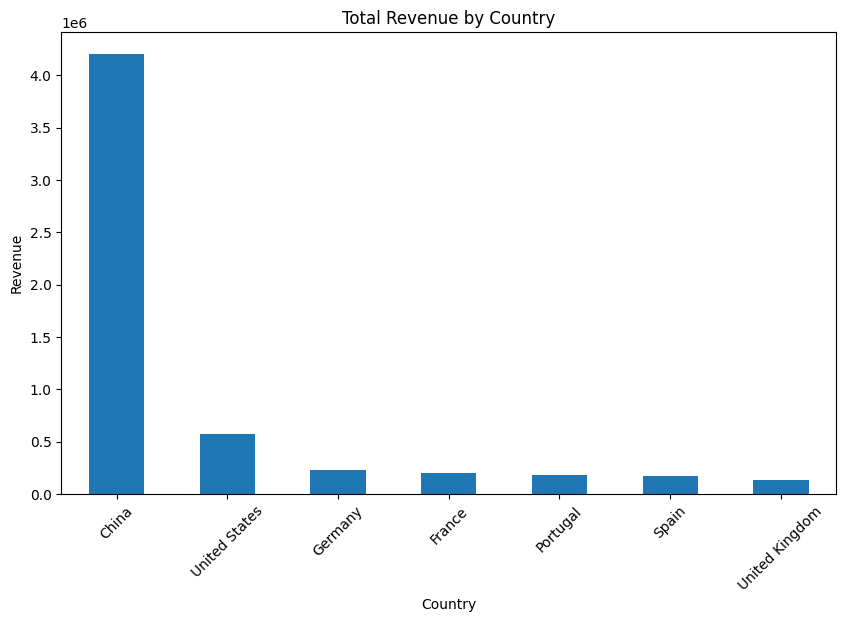

In [9]:
revenue_country.plot(kind='bar', figsize=(10,6), title='Total Revenue by Country')
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

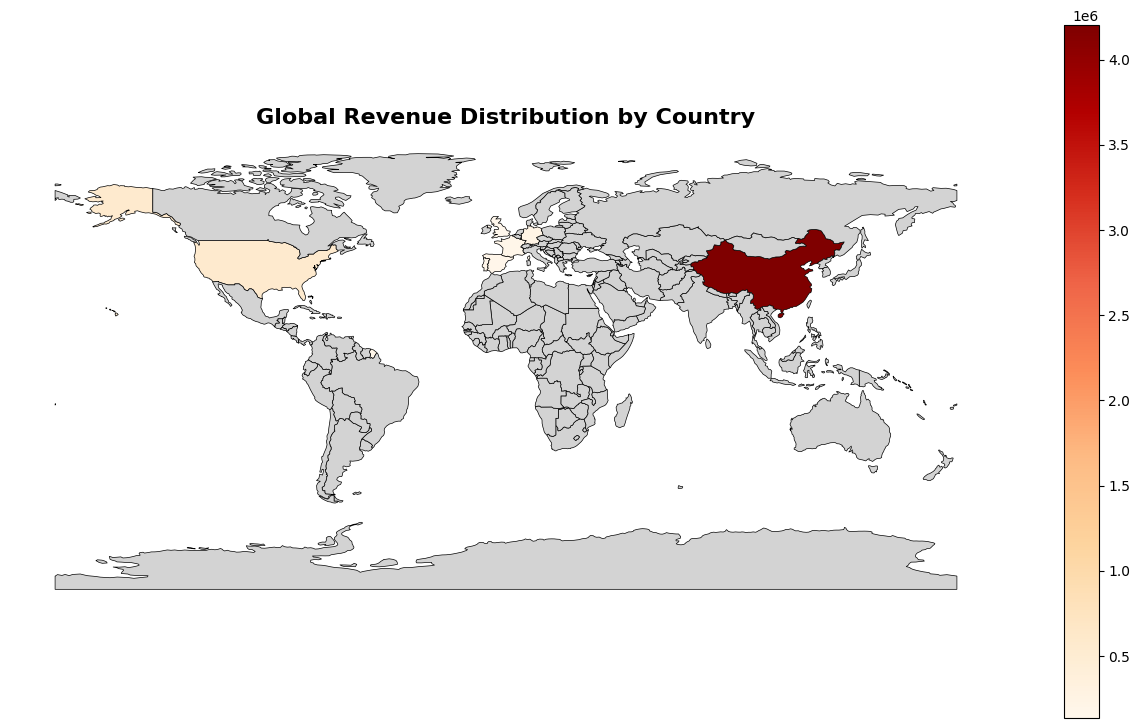

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Revenue by country
country_revenue = df_clean.groupby('Country', as_index=False)['Line Total'].sum()
country_revenue = country_revenue.rename(columns={'Line Total': 'Revenue'})

# Fix naming for map compatibility
country_revenue['Country'] = country_revenue['Country'].replace({
    'United States': 'United States of America'
})

# Load world map from official Natural Earth source
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Merge with your data
world_revenue = world.merge(country_revenue, how='left', left_on='NAME', right_on='Country')

# Plot
fig, ax = plt.subplots(figsize=(16, 9))

world_revenue.plot(
    column='Revenue',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "label": "No data"
    },
    ax=ax
)

ax.set_title('Global Revenue Distribution by Country', fontsize=16, fontweight='bold')
ax.axis('off')

plt.show()

### Interpretation of Results

The results show major differences in revenue across countries. China generates the highest revenue in the sample, followed at a considerable distance by the United States and Germany. This suggests that the strongest market concentration is located in Asia, while the other countries operate at a substantially lower scale.

From a strategic point of view, the strongest markets are natural candidates for consolidation and further investment, while lower-revenue markets may require targeted development strategies.

## 4. Sales Analysis by City

### a) Defining the problem
After examining country-level performance, the next step is to identify the cities generating the highest revenue. This provides a more detailed view of market concentration and helps identify the most successful urban markets.

### b) Information required for solving
The analysis uses the `City` variable and the `Line Total` variable from the cleaned dataset.

### c) Calculation methods, algorithms, calculation formulas used
The total revenue by city is calculated using the `groupby()` and `sum()` functions in pandas:

**Total Revenue = sum(Line Total) grouped by City**

The top 10 cities are then represented graphically with a bar chart.

### d) Presentation of results
The results consist of a ranked table of cities by total revenue and a bar chart showing the top 10 cities.

### e) Economic interpretation
City-level analysis helps identify the strongest local markets. Since expansion decisions in retail are often made at urban rather than national level, this step is particularly useful for strategic planning.

City
Guangzhou      1043306.20
Shanghai       1032264.77
Shenzhen        859775.08
Beijing         734704.44
Chongqing       532966.11
New York        162912.99
Los Angeles     156632.30
Houston         106369.03
Berlin           84398.74
Chicago          76694.08
Name: Line Total, dtype: float64


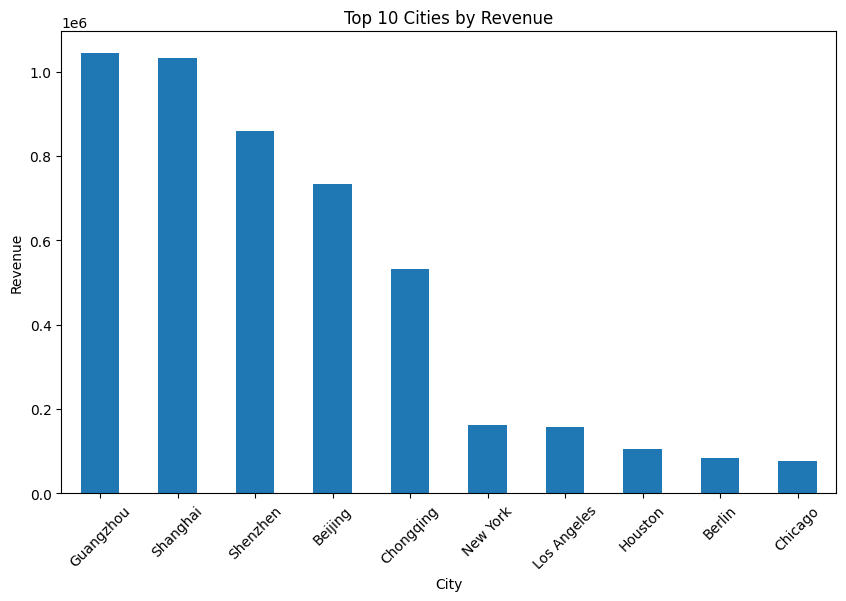

In [11]:
revenue_city = df_clean.groupby('City')['Line Total'].sum().sort_values(ascending=False)
print(revenue_city.head(10))

revenue_city.head(10).plot(kind='bar', figsize=(10,6), title='Top 10 Cities by Revenue')
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Interpretation of Results

The city analysis reveals that a relatively small number of cities generate a substantial share of total revenue. These cities represent the most dynamic and profitable urban markets in the dataset.

From an economic perspective, these high-performing cities can be considered priority areas for future expansion, additional investment, or intensified commercial activity.

## 5. Sales Analysis By Store Location (Geospatial Mapping)

### a) Defining the problem
Because store location is a fundamental factor in retail performance, it is useful to represent store results geographically. Spatial analysis helps visualize how revenue is distributed across locations and whether the strongest stores are concentrated in specific areas.

### b) Information required for solving
This step uses the variables `Store Name`, `Line Total`, `Latitude`, and `Longitude`.

### c) Calculation methods, algorithms, calculation formulas used
Store-level revenue is obtained by grouping the dataset by store name and summing `Line Total`. The result is then converted into a GeoDataFrame using latitude and longitude coordinates.

A world map is used as a base layer, and store locations are plotted as points with marker size proportional to total revenue.

### d) Presentation of results
The result is a map showing store locations and their relative economic importance through bubble size.

### e) Economic interpretation
Spatial representation helps identify the geographic concentration of the strongest stores and supports the interpretation of market differences across regions.

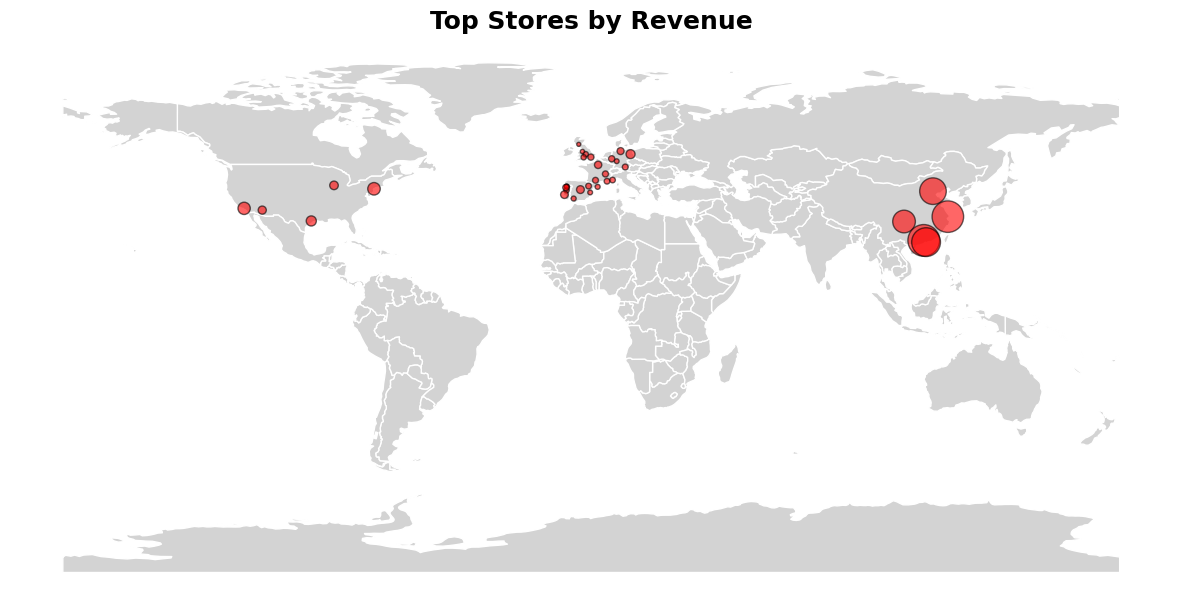

In [12]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# 1. Group by Store Name to get Total Revenue, and keep the Latitude and Longitude
store_geo = df_clean.groupby('Store Name').agg({
    'Line Total': 'sum',
    'Latitude': 'first',     # Keeps the first latitude value for that store
    'Longitude': 'first'     # Keeps the first longitude value for that store
}).reset_index()

# 2. Convert our pandas dataframe into a spatial GeoDataFrame
gdf_stores = gpd.GeoDataFrame(
    store_geo,
    geometry=gpd.points_from_xy(store_geo.Longitude, store_geo.Latitude)
)

# 3. Load the base world map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 4. Plot the map and the stores
fig, ax = plt.subplots(figsize=(15, 10))

# Draw the base map in a clean light grey
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# Draw the stores on top
gdf_stores.plot(ax=ax,
                markersize=gdf_stores['Line Total'] / 2000,
                color='red',
                alpha=0.6,
                edgecolor='black',
                label='Store Locations (Size = Revenue)')

plt.title('Top Stores by Revenue', fontsize=18, fontweight='bold')
plt.axis('off')
plt.show()

### Interpretation of Results

The spatial representation confirms that store performance is not evenly distributed geographically. Larger revenue bubbles are concentrated in a limited number of locations, indicating stronger local demand and more profitable market environments.

The analysis of revenue by city and by store produces similar results, as each city in the dataset corresponds to a single store. Therefore, city-level performance is equivalent to store-level performance in this context. This simplifies the strategic interpretation, since expansion decisions can be considered directly at city level.

## 6. Revenue Analysis by Product Category

### a) Defining the problem
The objective of this function is to identify which product categories generate the highest revenue and therefore contribute most to overall sales performance.

### b) Information required for solving
The analysis uses the variables `Category` and `Line Total`.

### c) Calculation methods, algorithms, calculation formulas used
The total revenue by category is calculated using the `groupby()` and `sum()` functions from pandas:

**Total Revenue = sum(Line Total) grouped by Category**

In addition, the percentage contribution of each category to total revenue is computed.

### d) Presentation of results
The results consist of a pie chart showing the share of each product category in total revenue and a table with category percentages.

### e) Economic interpretation
Category analysis is useful for understanding customer demand structure and identifying which product segments contribute most to business performance.

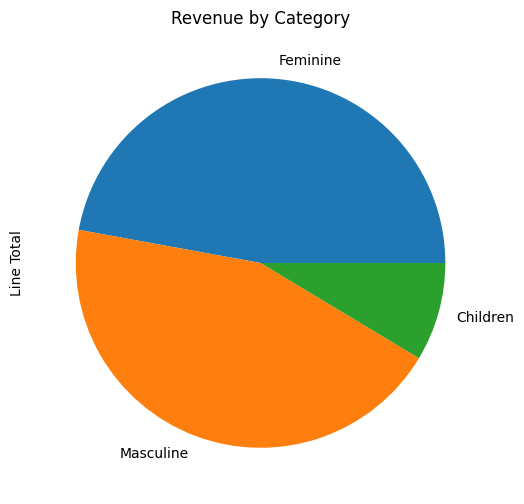

In [13]:
category_sales = df_clean.groupby('Category')['Line Total'].sum().sort_values(ascending=False)

category_sales.plot(kind='pie', figsize=(10,6), title='Revenue by Category')
plt.xticks(rotation=45)
plt.show()

In [14]:
category_share = (category_sales / category_sales.sum()) * 100
category_share

,Line Total
Category,
Feminine,47.128847
Masculine,44.259162
Children,8.611991


### Interpretation of Results

The analysis reveals differences in revenue across product categories, reflecting customer purchasing behavior and the relative importance of each segment in the company’s sales structure.

Higher-performing categories indicate stronger demand and should be prioritized in inventory planning, marketing strategies, and expansion decisions. Understanding category performance is essential for aligning product offerings with market preferences in different regions.

## 7. Encoding Methods

### a) Defining the problem
Machine learning and econometric models require numerical input. Since product categories are categorical variables stored as text, they must be transformed into numerical form before they can be used in quantitative analysis.

### b) Information required for solving
This step uses the `Category` variable from the cleaned dataset.

### c) Calculation methods, algorithms, calculation formulas used
The transformation is performed using one-hot encoding with the `get_dummies()` function from pandas. This method creates binary variables for each category.

### d) Presentation of results
The results consist of the newly created encoded columns corresponding to the original product categories.

### e) Economic interpretation
Encoding allows qualitative product information to be incorporated into formal numerical models.

In [15]:
# Apply one-hot encoding to the Category column
df_ml = pd.get_dummies(df_clean, columns=['Category'], drop_first=True)

# Show the new binary columns created at the end of the dataframe
df_ml.filter(like='Category').head()

,Sub Category,Category_Feminine,Category_Masculine
0,"Girl and Boy (1-5 years, 6-14 years)",False,False
1,Shirts and Blouses,True,False
2,Shirts,False,True
3,Dresses and Jumpsuits,True,False
4,Suits and Sets,True,False


### Interpretation of Results

Transforming categorical variables into numerical form enables the inclusion of product categories in quantitative models and statistical analysis.

This allows the company to measure the role of different product segments in sales performance. From a strategic perspective, this supports data-driven decisions regarding product assortment, inventory allocation, and targeted marketing campaigns.

## 8. Store-Level Aggregation and Scaling

### a) Defining the problem
The clustering analysis aims to group stores according to their overall commercial performance. Since clustering is performed at store level, the transactional data must first be aggregated into meaningful store-level indicators.

### b) Information required for solving
The following store-level indicators are used:
- Total Revenue
- Total Quantity Sold
- Average Transaction Revenue
- Average Discount

These variables represent different dimensions of store performance, including financial output, sales volume, transaction value, and pricing strategy.

### c) Calculation methods
The transactional dataset is first aggregated by store. The resulting indicators are then standardized using `StandardScaler` so that variables measured on different numerical scales contribute comparably to the clustering algorithm.

The standardization formula is:

**z = (x - μ) / σ**

### d) Presentation of results
The resulting dataset contains one observation per store, together with both the original business metrics and their standardized equivalents.

### e) Economic interpretation
Aggregating before scaling ensures that the clustering process compares stores as business units rather than individual transactions. This provides a more meaningful basis for identifying groups of stores with similar commercial performance.

In [16]:
# Aggregate transaction-level data into store-level performance metrics
store_metrics = (
    df_ml.groupby('Store Name')
    .agg(
        Total_Revenue=('Line Total', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Average_Transaction_Revenue=('Line Total', 'mean'),
        Average_Discount=('Discount', 'mean')
    )
    .reset_index()
)

# Select the variables used for clustering
cluster_features = [
    'Total_Revenue',
    'Total_Quantity',
    'Average_Transaction_Revenue',
    'Average_Discount'
]

# Standardize store-level variables
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    store_metrics[cluster_features]
)

scaled_columns = [
    'Scaled_Total_Revenue',
    'Scaled_Total_Quantity',
    'Scaled_Average_Transaction_Revenue',
    'Scaled_Average_Discount'
]

store_metrics[scaled_columns] = scaled_features

store_metrics.head()

,Store Name,Total_Revenue,Total_Quantity,Average_Transaction_Revenue,Average_Discount,Scaled_Total_Revenue,Scaled_Total_Quantity,Scaled_Average_Transaction_Revenue,Scaled_Average_Discount
0,Store Barcelona,26188.53,767,37.573214,0.132712,-0.473930,-0.847089,-0.414711,1.207925
1,Store Beijing,734704.44,2387,336.249172,0.118009,1.985977,0.851102,2.388843,-0.220844
2,Store Berlin,84398.74,2344,39.735753,0.131733,-0.271829,0.806026,-0.394413,1.112783
3,Store Birmingham,30016.84,1190,28.237855,0.118015,-0.460639,-0.403672,-0.502339,-0.220271
4,Store Braga,20003.73,566,38.321322,0.100670,-0.495403,-1.057790,-0.407689,-1.905795


### Interpretation of Results

The selected variables were successfully standardized, which makes them comparable despite their different numerical ranges.

From an economic perspective, scaling improves the technical quality of the models by ensuring that both revenue-related and quantity-related variables contribute fairly to market segmentation analysis. This allows the identification of store groups based on actual performance patterns rather than on differences in units of measurement.

## 9. Market Segmentation through Clustering

### a) Defining the problem
To support strategic decision-making and expansion analysis, stores are grouped according to similarities in their commercial performance. The objective is to identify distinct store profiles rather than evaluating stores individually.

### b) Information required for solving
The clustering analysis uses four standardized store-level indicators:

- Total Revenue
- Total Quantity Sold
- Average Transaction Revenue
- Average Discount

Together, these variables capture financial performance, sales volume, transaction value, and discount behaviour.

### c) Calculation methods
K-Means clustering is applied to the standardized store-level indicators.

The K-Means algorithm groups observations by minimizing within-cluster variation:

**Σ Σ ||xᵢ - μⱼ||²**

where:
- `xᵢ` represents a store
- `μⱼ` represents the centroid of cluster `j`

Rather than selecting the number of clusters arbitrarily, values of `k` from 2 to 6 are evaluated using both the Elbow Method and Silhouette Score.

### d) Presentation of results
The analysis presents the Elbow curve, Silhouette Scores for each tested value of `k`, final cluster assignments, average business metrics for each cluster, and a visual comparison of store performance.

### e) Economic interpretation
The resulting segmentation identifies groups of stores with different commercial profiles and provides a data-driven basis for comparing store performance, allocating resources, and evaluating potential expansion opportunities.

### Selecting the Number of Clusters

Before fitting the final K-Means model, several values of `k` are evaluated using two complementary methods:

- **Elbow Method:** evaluates how quickly within-cluster variation decreases as more clusters are added.
- **Silhouette Score:** measures how well each observation fits within its assigned cluster relative to neighbouring clusters.

A higher Silhouette Score indicates clearer separation between clusters. The final value of `k` is selected by considering both statistical performance and business interpretability.

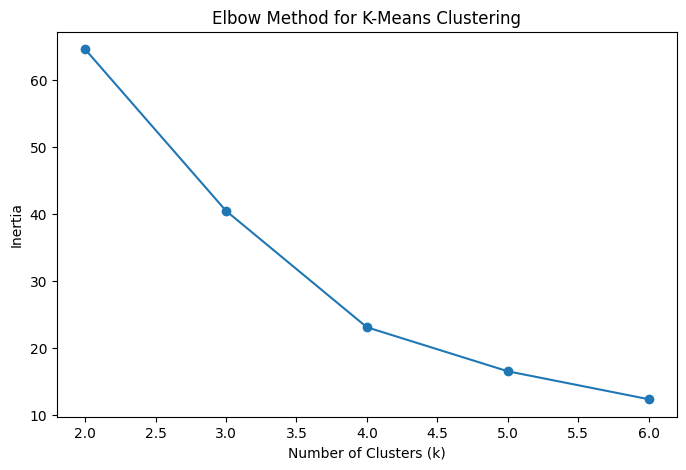

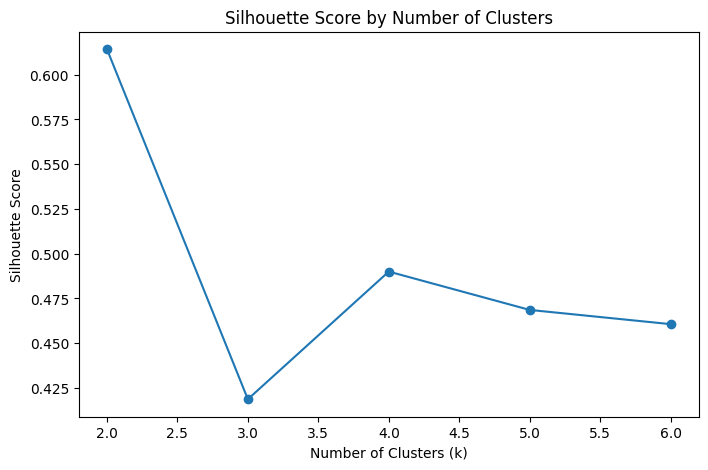

k = 2: Silhouette Score = 0.614
k = 3: Silhouette Score = 0.419
k = 4: Silhouette Score = 0.490
k = 5: Silhouette Score = 0.469
k = 6: Silhouette Score = 0.461


In [17]:
X_cluster = store_metrics[scaled_columns]

inertias = []
silhouette_scores = []

# Do not test more clusters than the number of stores allows
max_k = min(6, len(store_metrics) - 1)
k_values = range(2, max_k + 1)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_cluster)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels)
    )

# Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means Clustering')
plt.show()

# Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.3f}")

### Cluster Selection

The evaluation indicates that **k = 2** provides the strongest cluster separation, achieving the highest Silhouette Score of **0.614**.

Although additional cluster configurations were evaluated, their Silhouette Scores were considerably lower. Therefore, two clusters were selected for the final K-Means model.

From a business perspective, this segmentation allows stores to be divided into two distinct performance profiles based on revenue, sales volume, average transaction revenue, and discount behaviour.

In [18]:
# Final K-Means model using the selected number of clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

store_metrics['Cluster'] = kmeans.fit_predict(
    store_metrics[scaled_columns]
)

# Display store-level metrics and assigned cluster
store_metrics[
    [
        'Store Name',
        'Total_Revenue',
        'Total_Quantity',
        'Average_Transaction_Revenue',
        'Average_Discount',
        'Cluster'
    ]
].sort_values('Cluster')

,Store Name,Total_Revenue,Total_Quantity,Average_Transaction_Revenue,Average_Discount,Cluster
0,Store Barcelona,26188.53,767,37.573214,0.132712,0
2,Store Berlin,84398.74,2344,39.735753,0.131733,0
3,Store Birmingham,30016.84,1190,28.237855,0.118015,0
4,Store Braga,20003.73,566,38.321322,0.100670,0
6,Store Chicago,76694.08,1961,42.774166,0.116704,0
5,Store Bristol,29667.80,1147,28.775752,0.134869,0
9,Store Frankfurt am Main,23683.86,640,41.333089,0.111344,0
8,Store Coimbra,29228.09,839,38.407477,0.134231,0
14,Store Houston,106369.03,2711,42.908040,0.117729,0
13,Store Hamburg,50550.69,1448,39.369696,0.131854,0


In [19]:
cluster_profiles = (
    store_metrics
    .groupby('Cluster')[
        [
            'Total_Revenue',
            'Total_Quantity',
            'Average_Transaction_Revenue',
            'Average_Discount'
        ]
    ]
    .mean()
    .round(2)
)

cluster_profiles

,Total_Revenue,Total_Quantity,Average_Transaction_Revenue,Average_Discount
Cluster,,,,
0,49707.39,1387.7,38.31,0.12
1,840603.32,2699.4,342.41,0.12


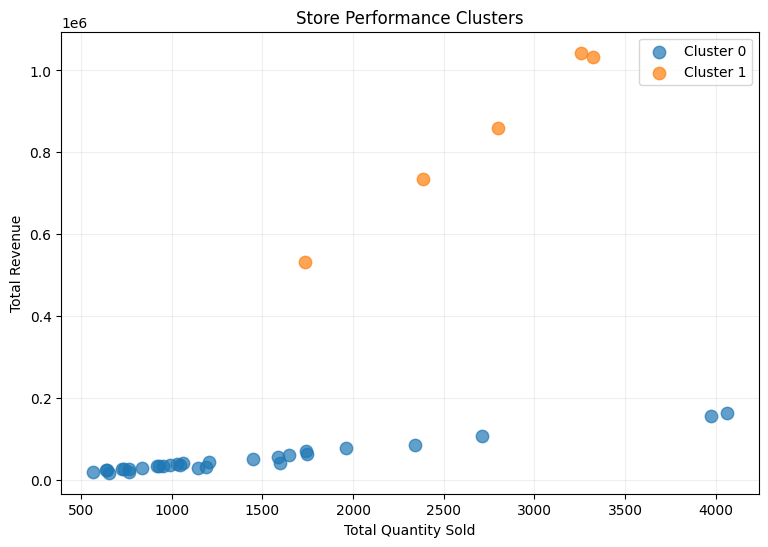

In [22]:
plt.figure(figsize=(9, 6))

for cluster in sorted(store_metrics['Cluster'].unique()):
    cluster_data = store_metrics[
        store_metrics['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['Total_Quantity'],
        cluster_data['Total_Revenue'],
        label=f'Cluster {cluster}',
        s=80,
        alpha=0.7
    )

plt.xlabel('Total Quantity Sold')
plt.ylabel('Total Revenue')
plt.title('Store Performance Clusters')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Interpretation of Results

The K-Means analysis identified two distinct store performance profiles, with **k = 2** achieving the highest Silhouette Score of **0.614**, indicating a relatively clear separation between the two groups.

**Cluster 0** contains the majority of stores and represents a standard-performance profile. These stores generate lower total revenue and lower average transaction revenue, while maintaining moderate sales volumes.

**Cluster 1** represents a smaller group of high-value stores. These stores generate substantially higher total revenue and average transaction revenue. Although some stores in Cluster 0 sell comparable or even higher quantities of products, Cluster 1 generates significantly greater financial value, suggesting that the distinction between the groups is not driven solely by sales volume.

Average discount levels are approximately the same across both clusters, indicating that discount intensity does not appear to be a major factor differentiating store performance.

From a business perspective, the segmentation highlights different commercial profiles within the retail network. The characteristics of the high-value cluster may serve as useful benchmarks when evaluating store strategy, resource allocation, and potential expansion opportunities.

## 10. Multiple Regression with Statsmodels

### a) Defining the problem
After the descriptive and clustering analysis, the next step is to estimate a regression model in order to evaluate the relationship between revenue and selected explanatory variables. The objective is to determine whether sales volume and discount policy have a statistically significant effect on revenue.

### b) Information required for solving
This step uses:
- dependent variable: `Line Total`
- independent variables: `Quantity`, `Discount`

These variables are relevant because they capture the link between sales volume, pricing strategy, and transaction-level revenue.

### c) Calculation methods, algorithms, calculation formulas used
The model is estimated using the `OLS` (Ordinary Least Squares) method from the statsmodels package.

The general linear regression model has the following form:

**Yᵢ = β₀ + β₁X₁ᵢ + β₂X₂ᵢ + εᵢ**

where:
- `Yᵢ` is the dependent variable (`Line Total`)
- `X₁ᵢ` and `X₂ᵢ` are the explanatory variables (`Quantity` and `Discount`)
- `β₀` is the intercept
- `β₁` and `β₂` are the coefficients
- `εᵢ` is the error term

The model estimates how changes in quantity and discount are associated with revenue, while holding the other variable constant.

### d) Presentation of results
The results consist of the OLS regression summary table, including estimated coefficients, significance levels, and the R-squared indicator.

### e) Economic interpretation
Regression analysis allows the estimation of the relationship between revenue and the selected explanatory variables while holding the others constant. This makes it possible to evaluate how quantity and discount are associated with sales performance.

In [23]:
# Define independent variables (X) and dependent variable (y)
X = df_ml[['Quantity', 'Discount']]
X = sm.add_constant(X)
y = df_ml['Line Total']

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Print the summary statistics
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Line Total   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1127.
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:14:07   Log-Likelihood:            -3.3784e+05
No. Observations:               50000   AIC:                         6.757e+05
Df Residuals:                   49997   BIC:                         6.757e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.7511      2.777      6.752      0.0

### Interpretation of Results

The regression results indicate statistically significant associations between quantity, discount, and transaction revenue. Higher quantities are associated with higher transaction revenue, while higher discounts are associated with lower transaction revenue, holding the other variable constant.

However, the model has a low R-squared value of approximately **0.043**, meaning that quantity and discount explain only a small proportion of the overall variation in transaction revenue. Therefore, these relationships should not be interpreted as providing a complete explanation of sales performance.

Other factors such as product category, store location, pricing differences, seasonality, and customer behaviour are likely to account for a substantial share of the remaining variation.

From a business perspective, the results suggest that sales volume and discount policy are relevant to transaction revenue, while also highlighting the need to consider a broader set of commercial and market factors when analysing retail performance.

## Conclusion

This project analyzed a multinational fashion retail dataset in order to evaluate market performance, product structure, and expansion potential using data-driven methods.

The analysis revealed several key findings:

- **Market performance differs significantly across countries**, with China emerging as the strongest market in terms of total revenue, followed by the United States and Germany. This indicates a high level of demand concentration in specific regions.

- **City-level analysis showed that a small number of urban markets generate a large share of total revenue**, confirming the importance of location in retail performance.

- **Product category analysis highlighted differences in customer demand**, indicating that certain categories contribute more significantly to total sales and should be prioritized in inventory and marketing strategies.

- **Clustering analysis identified two distinct store performance profiles**, separating a smaller group of high-value stores from the network's standard-performance profile. The high-value stores generate substantially greater revenue and average transaction value, while discount levels remain similar across the two groups.

- **Regression analysis identified statistically significant associations between quantity, discount, and revenue**, although the model's low explanatory power indicates that these variables account for only a limited share of revenue variation.

Overall, the project demonstrates how data analysis can support strategic decision-making in the retail sector. By combining descriptive analytics, statistical analysis, spatial analysis, and machine learning-based segmentation, retailers can better understand market dynamics, compare store performance, allocate resources more effectively, and identify potential expansion opportunities.

Future work could include incorporating additional variables such as customer demographics, seasonal trends, and competitive factors in order to build more accurate predictive models and further refine expansion strategies.